## **Libraries**

In [4]:
import numpy as np
import pandas as pd
import os
import cv2
from pathlib import Path
import segmentation_models_pytorch as smp
import torch.nn.functional as F
from fontTools.ufoLib import DATA_DIRNAME
from torchvision.transforms import transforms
import torch.nn as nn
import torch
import albumentations as A
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

from data_preprocessing import RLEprocessor
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed()
warnings.filterwarnings("ignore")

In [5]:
CONFIG = {
    "Height": 256,
    "Width": 1600,
    "n_classes": 4,
    "val_split": 0.2,
    "batch_size": 8,
    "num_workers": 2,
    "epochs": 50,
    "lr": 1e-4,
    "Seed": 42,
    "THRESHOLD": 0.5,
    "n_channels": 3
}

DATA_DIR = Path("./Dataset")
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR = DATA_DIR / "test_images"
TRAIN_CSV = DATA_DIR / "train.csv"

## Data

In [8]:
cd ..

/Users/thachphung/Documents/Graduation Project


In [9]:
df = pd.read_csv(TRAIN_CSV)
print(len(df))
df.info()

7095
<class 'pandas.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ImageId        7095 non-null   str  
 1   ClassId        7095 non-null   int64
 2   EncodedPixels  7095 non-null   str  
dtypes: int64(1), str(2)
memory usage: 166.4 KB


In [10]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


The number of all images is  12568
The number of all images with defect  6666
The number of all images without defect  5902


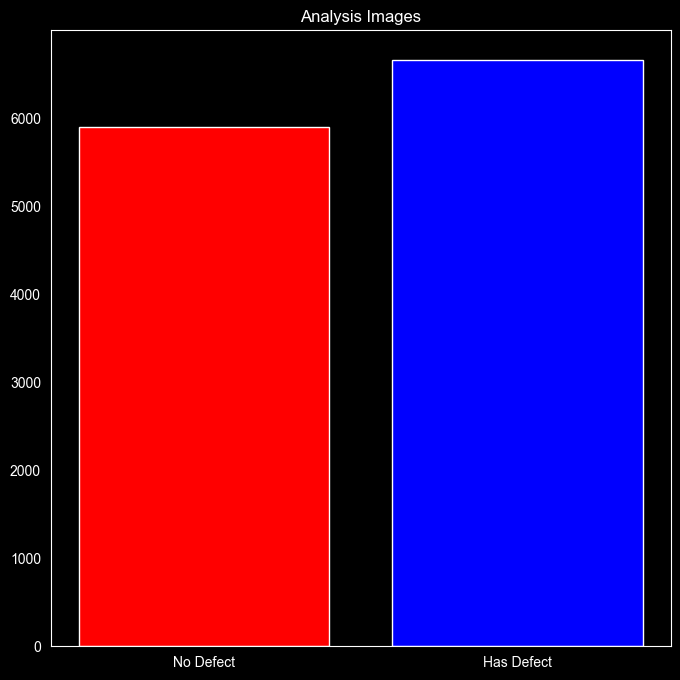

In [11]:
# Get all images from training Image
all_images = os.listdir(TRAIN_DIR)
all_images = [img for img in all_images if img.endswith((".jpg", ".png"))]

# Image id from csv
defect_images = df["ImageId"].unique().tolist()

# Image no defect
no_defect_images = set(all_images) - set(defect_images)

print("The number of all images is ", len(all_images))
print("The number of all images with defect ", len(defect_images))
print("The number of all images without defect ", len(no_defect_images))

# Bar plot
plt.figure(figsize=(8, 8))
plt.bar(["No Defect", "Has Defect"], [len(no_defect_images), len(defect_images)], color=["red", "blue"])
plt.title("Analysis Images")
plt.grid(False)
plt.show()

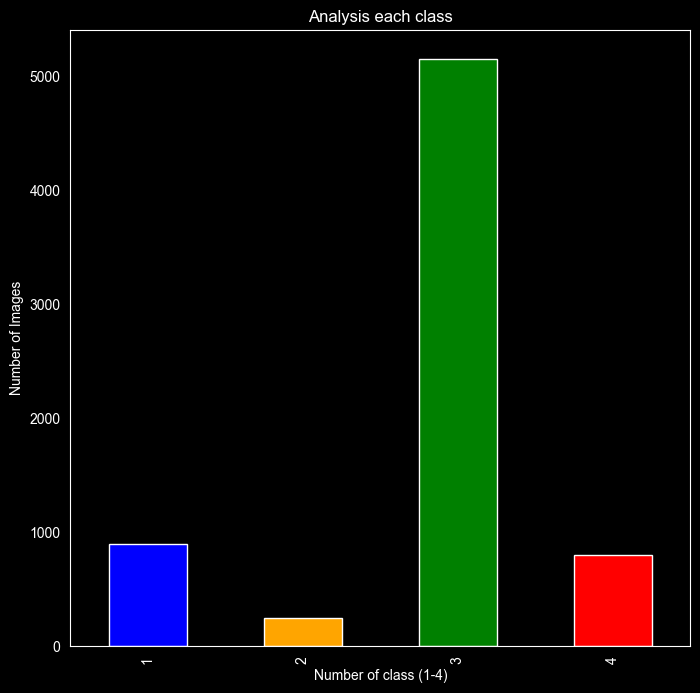

In [12]:
class_counts = (df[df["EncodedPixels"].notnull()].groupby("ClassId")["ImageId"].nunique())

# Total samples
total_images = df["ImageId"].nunique()
plt.figure(figsize=(8,8))
class_counts.plot(kind="bar", color=["blue","orange","green","red"])
plt.title("Analysis each class")
plt.ylabel("Number of Images")
plt.xlabel("Number of class (1-4)")
plt.grid(False)
plt.show()

### Preprocessing

In [13]:
class RLEprocessor:
    """RLE encoding and decoding"""

    @staticmethod
    def rle_decoder(rle_str, shape=(CONFIG['Height'], CONFIG['Width'])) -> np.ndarray:
        rle_list = rle_str.split()  # convert to list
        assert isinstance(rle_list, list)  # if is list, be passed
        start, length = [np.asarray(x, dtype=int) for x in (rle_list[0::2], rle_list[1::2])]
        # start = [rle_list[x] - 1 for x in range(0, len(rle_list), 2)]
        # length = [rle_list[x] for x in range(1, len(rle_list), 2)]
        start -= 1
        ends = start + length
        image = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for start, end in zip(start, ends):
            image[start:end] = 1
        return image.reshape(shape, order='F')

    @staticmethod
    def build_masks(df: pd.DataFrame, image_id: str) -> np.ndarray:
        mask = np.zeros((CONFIG["Height"], CONFIG['Width'], CONFIG['n_classes']), dtype=np.uint8)

        for i in range(1, 5):
            rle = df.loc[
                (df["ImageId"] == image_id) & (df['ClassId']== i), "EncodedPixels"
            ]
            if len(rle) > 0:
                rle = rle.values[0]
                if pd.notna(rle):
                    mask[:,:, i-1] = RLEprocessor.rle_decoder(rle)
        return mask

    @staticmethod
    def rle_encoder(mask):
        pixels = mask.T.flatten(order='F')
        pixels = np.concatenate([[0], pixels, [0]])
        runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Use 0 to covert tuple to nparray
        runs[1::2] -= runs[::2]
        return ' '.join(str(x) for x in runs)

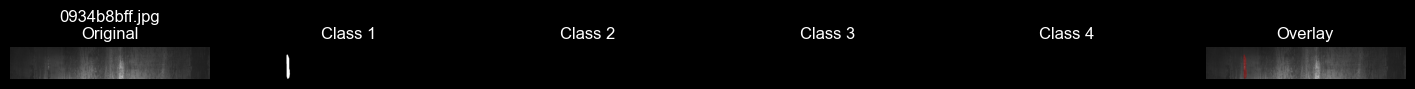

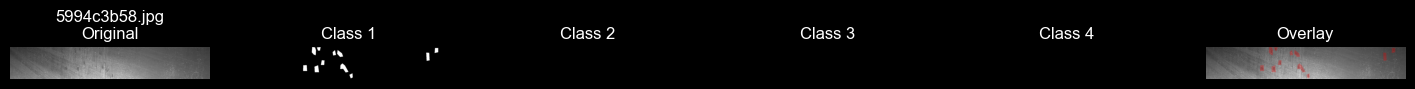

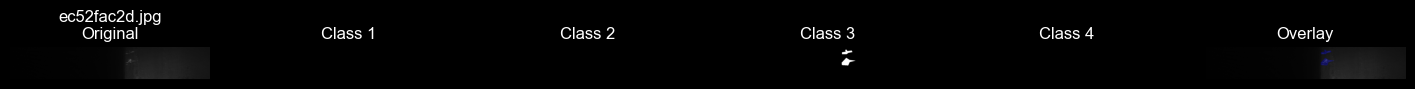

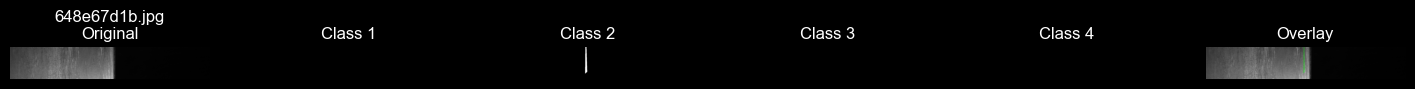

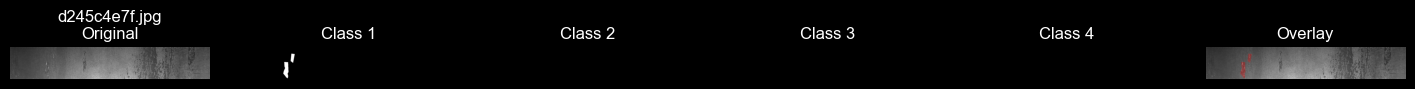

In [15]:
sample_images = df["ImageId"].drop_duplicates().sample(5, random_state=42).tolist()

for image_id in sample_images:
    img_path = TRAIN_DIR / image_id
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    masks = RLEprocessor.build_masks(df, image_id)

    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1)
    plt.imshow(img)
    plt.title(f"{image_id}\nOriginal")
    plt.axis("off")

    # Sınıf maskeleri
    for i in range(4):
        plt.subplot(1,6,i+2)
        plt.imshow(masks[..., i], cmap="gray")
        plt.title(f"Class {i+1}")
        plt.axis("off")

    # Overlay
    overlay = img.copy()
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]  # R, G, B, Sarı
    for i in range(4):
        mask = masks[..., i].astype(bool)
        overlay[mask] = (0.7*overlay[mask] + 0.3*np.array(colors[i])).astype(np.uint8)

    plt.subplot(1,6,6)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

### Augmentation

In [16]:
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9,1.1), translate_percent=(0.02,0.02), rotate=(-5,5), p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.RandomBrightnessContrast(p=0.4),
        A.Resize(CONFIG['Height'], CONFIG["Width"], interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ], is_check_shapes=False)
val_transform = A.Compose([
        A.Resize(CONFIG['Height'], CONFIG["Width"], interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

### Build data

In [17]:
class SteverstalDataset(Dataset):
    """PyTorch Dataset for Severstal"""

    def __init__(self, image_ids, df: pd.DataFrame, image_dir, transform=None, load_rgb=True):
        self.df = df
        self.image_dir = Path(image_dir)
        self.image_ids= list(image_ids)
        self.transform = transform
        self.load_rgb = load_rgb

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Image not found: {image_id}")
        if self.load_rgb:
            img = np.repeat(img[..., None], 3, axis=2)  # (H,W,3)
        return img


    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = self._read_image(image_id)
        mask = RLEprocessor.build_masks(self.df, image_id)

        if self.transform:
            output = self.transform(image=image, mask=mask)
            image, mask = output['image'], output['mask'].permute(2, 0, 1) # (C, H, W)
        else:
            image = torch.from_numpy(image.transpose(2,0,1)).float()
            mask = torch.from_numpy(mask.transpose(2,0,1)).float()

        meta = {"image_id": image_id}
        return {
            'image': image,   # (3, H, W)
            'mask': mask,     # (4, H, W)
            'image_id': image_id
        }


# --- Collate function ---
def collate_fn(batch):
    images, masks, metas = zip(*batch)
    images = torch.stack(images)
    masks = torch.stack(masks)
    return images, masks, metas

### Dataset , Dataloader

In [18]:
train_ids, valid_ids = train_test_split(
    df["ImageId"].unique(),
    test_size=CONFIG["val_split"],
    random_state=CONFIG["Seed"]
)

In [19]:
train_ds = SteverstalDataset(train_ids, df, TRAIN_DIR, transform=train_transform)
val_ds = SteverstalDataset(valid_ids, df, TRAIN_DIR, transform=val_transform)

In [20]:
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

In [21]:
batch = next(iter(train_loader))

In [22]:
images = batch['image']

In [23]:
images.shape[0]

8

In [25]:
images.shape

torch.Size([8, 3, 256, 1600])

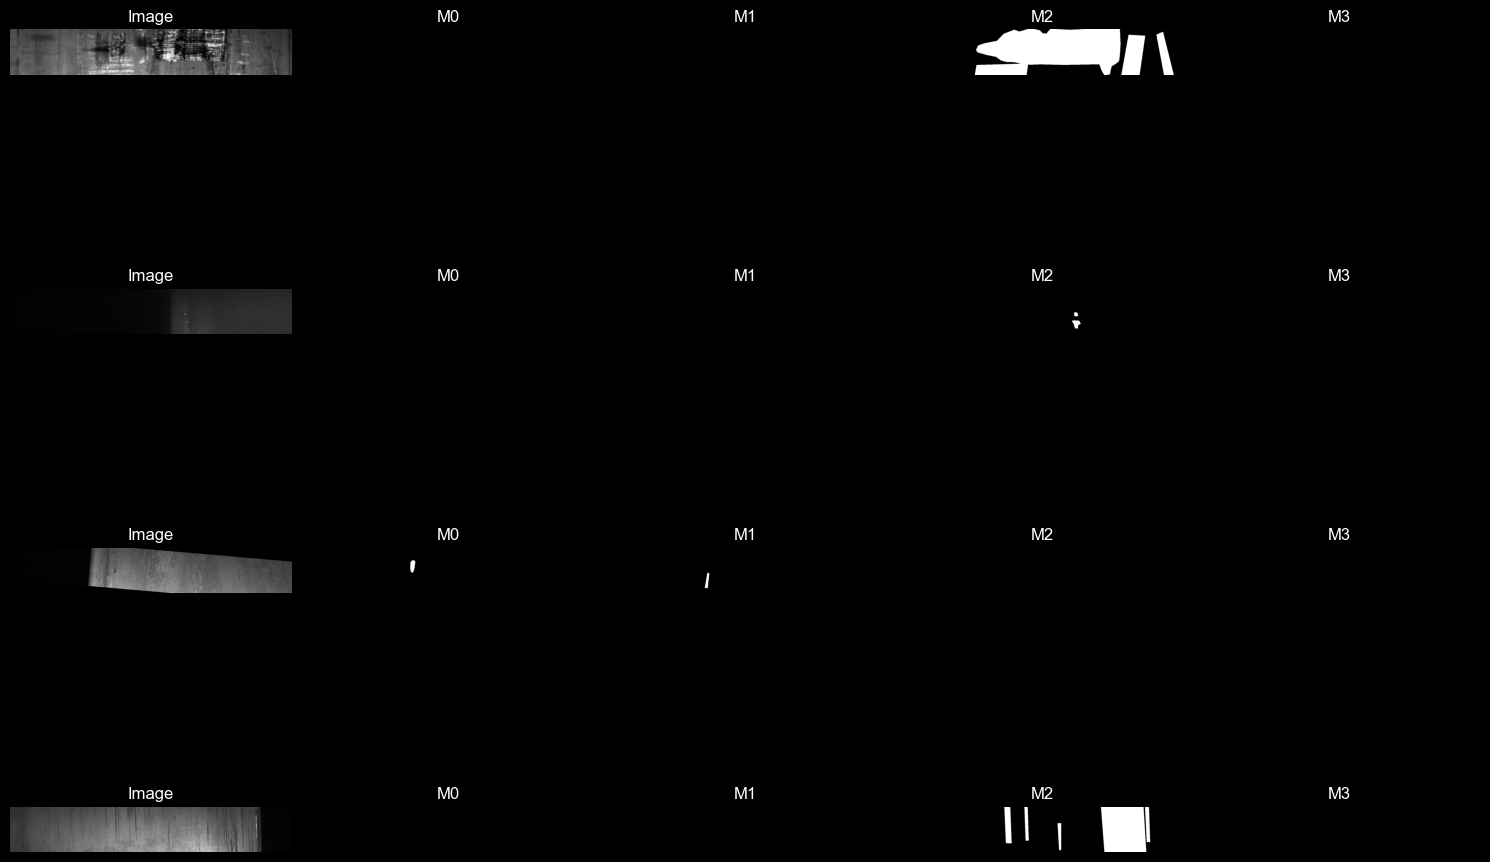

In [26]:
batch = next(iter(train_loader))
images = batch['image']
masks = batch['mask']
B = images.shape[0]  # batch size
num_show = min(4, B)  # hiển thị tối đa 4 sample

plt.figure(figsize=(15, 3 * num_show))

for i in range(num_show):
    img = images[i].cpu().numpy()[0]   # (H, W)
    mask = masks[i].cpu().numpy()      # (4, H, W)
    #print(mask[i])

    # unnormalize nếu cần
    img = (img * 0.5) + 0.5

    # ===== Image =====
    plt.subplot(num_show, 5, i*5 + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Image")
    plt.axis('off')

    # ===== 4 Masks =====
    for j in range(4):
        plt.subplot(num_show, 5, i*5 + 2 + j)
        plt.imshow(mask[j,:,:], cmap='gray')
        plt.title(f"M{j}")
        plt.axis('off')

plt.tight_layout()
plt.show()

## Model

In [27]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv_block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            ConvBlock(in_channels, out_channels, kernel_size, padding),
        )
    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, bilinear=True):
        super().__init__()
        if bilinear:
            self.conv_trans = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv_block = ConvBlock(in_channels, out_channels, kernel_size, padding)
        else:
            self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv_block = ConvBlock(in_channels, out_channels, kernel_size, padding)

    def forward(self, x1, x2):
        # B, C, H, W
        x1= self.conv_trans(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2))
        x = torch.cat([x2, x1], dim=1) # concat by channel
        return self.conv_block(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        return self.conv(x)


In [28]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super().__init__()
        self.inc = ConvBlock(n_channels, 64, kernel_size=3, padding=1)
        self.down1 = Encoder(64, 128, 3, 1)
        self.down2 = Encoder(128, 256, 3, 1)
        self.down3 = Encoder(256, 512, 3, 1)
        factor = 2 if bilinear else 1
        self.down4 = Encoder(512, 1024 // factor, 3, 1)
        self.bottom_neck = ConvBlock(1024//factor, 1024//factor, kernel_size=1, padding=0)
        self.up1 = Decoder(1024, 512//factor, 3, 1, bilinear=bilinear)
        self.up2 = Decoder(512, 256//factor, 3, 1, bilinear=bilinear)
        self.up3 = Decoder(256, 128//factor, 3, 1, bilinear=bilinear)
        self.up4 = Decoder(128, 64, 3, 1, bilinear=bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x) # 64
        x2 = self.down1(x1) # 128
        x3 = self.down2(x2) # 256
        x4 = self.down3(x3) #512
        x5 = self.down4(x4) # 1024
        x5 = self.bottom_neck(x5) # 1024
        x = self.up1(x5, x4) # 512
        x = self.up2(x, x3) # 256
        x = self.up3(x, x2) # 128
        logits = self.up4(x, x1) # 64
        return self.outc(logits)

## Metrics

In [29]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p = probs.view(probs.size(0), probs.size(1), -1)
        t = targets.view(targets.size(0), targets.size(1), -1)
        inter = (p*t).sum(2); den = p.sum(2)+t.sum(2)
        dice = (2*inter + self.smooth) / (den + self.smooth)
        return 1.0 - dice.mean()

class WeightedFocalDiceLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, lam_f=0.7, lam_d=0.3):
        super().__init__()
        self.w = class_weights
        self.g = gamma
        self.lf = lam_f
        self.ld = lam_d
        self.dice = DiceLoss()

    def forward(self, logits, targets, return_details=False):
        probs = torch.sigmoid(logits)
        eps = 1e-8

        # BCE
        bce = -(targets * torch.log(probs + eps) +
                (1 - targets) * torch.log(1 - probs + eps))

        # Focal loss
        pt = torch.where(targets == 1, probs, 1 - probs)
        fw = (1 - pt) ** self.g

        if self.w is not None:
            fw = fw * logits.new_tensor(self.w).view(1, -1, 1, 1)

        focal = (fw * bce).mean()
        dice = self.dice(logits, targets)

        loss = self.lf * focal + self.ld * dice

        if return_details:
            return loss, {"focal": focal.item(), "dice": dice.item()}
        return loss

@torch.no_grad()
def dice_coefficient(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((2,3)); den = preds.sum((2,3))+targets.sum((2,3))
    dice = (2*inter+eps)/(den+eps)
    return dice.mean()

@torch.no_grad()
def dice_per_class(logits, targets, thr=CONFIG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((0,2,3)); den = preds.sum((0,2,3))+targets.sum((0,2,3))
    return ((2*inter+eps)/(den+eps)).cpu().tolist()

## Training

In [30]:
for batch in val_loader:
    images = batch['image']
    print(images.shape)
    masks = batch["mask"]
    print(masks.shape)
    break

torch.Size([8, 3, 256, 1600])
torch.Size([8, 4, 256, 1600])


In [31]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.to(device)
    model.train()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Train", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        bs = imgs.size(0)
        n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(outputs, masks).item() * bs
    return {"loss": run_loss / n, "dice": run_dice / n}

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.to(device)
    model.eval()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for batch in tqdm(loader, desc="Valid", leave=False):
        imgs = batch["image"].to(device)
        masks = batch["mask"].to(device)
        out = model(imgs)
        loss = criterion(out, masks)
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(out, masks).item() * bs
    return {"loss": run_loss/n, "dice": run_dice/n}


In [32]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=CONFIG["epochs"],save_path="best_model.pth"):
    best_dice = -1.0
    history = {"train": [],
               "valid": []}
    for epoch in range(1, num_epochs+1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        all_val_dice = []
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            all_val_dice.append(dice_per_class(outputs, masks))
        val_metrics["per_class_dice"] = np.mean(all_val_dice, axis=0).tolist()

        print(f"Train Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}")
        print(f"Valid Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}")

        history["train"].append({**train_metrics, "lr": optimizer.param_groups[0]["lr"]})
        history["valid"].append(val_metrics)

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved at epoch {epoch} (dice={best_dice:.4f})")

    print(f"Training finished. Best Dice = {best_dice:.4f}")
    return history


In [50]:
model = UNet(n_channels=CONFIG["n_channels"], n_classes=CONFIG["n_classes"])
criterion = WeightedFocalDiceLoss(class_weights=[0.12,0.03,0.72,0.11])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [51]:
state_dict = torch.load("./model/best_model_track_1.pth", map_location="cpu")

new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [52]:
dict = validate_one_epoch(model, val_loader, criterion, device)

In [54]:
history = fit(model, train_loader, val_loader, optimizer, criterion, device, CONFIG['epochs'])


Epoch 1/50


RuntimeError: MPS backend out of memory (MPS allocated: 17.20 GiB, other allocations: 802.95 MiB, max allowed: 18.13 GiB). Tried to allocate 800.00 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

### Visualization

In [37]:
import torch
import matplotlib.pyplot as plt

def visualize_prediction(image, mask, pred, threshold=0.5):
    """
    image: (3, H, W)
    mask:  (C, H, W)
    pred:  (C, H, W) (logits hoặc prob)
    """

    # chuyển về numpy
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.cpu().numpy()
    pred = pred.cpu().detach().numpy()

    # nếu pred là logits → sigmoid
    pred = 1 / (1 + np.exp(-pred))

    # threshold
    pred = (pred > threshold).astype(int)

    num_classes = mask.shape[0]

    fig, axes = plt.subplots(3, num_classes, figsize=(4*num_classes, 10))

    for i in range(num_classes):
        # Image
        axes[0, i].imshow(image)
        axes[0, i].set_title(f"Image (Class {i})")
        axes[0, i].axis("off")

        # Ground truth
        axes[1, i].imshow(mask[i], cmap="gray")
        axes[1, i].set_title(f"GT Mask {i}")
        axes[1, i].axis("off")

        # Prediction
        axes[2, i].imshow(pred[i], cmap="gray")
        axes[2, i].set_title(f"Pred Mask {i}")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
batch = next(iter(val_loader))

In [45]:
images = batch["image"].to(device)
images[1].shape

torch.Size([3, 256, 1600])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240345..2.552854].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240345..2.552854].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240345..2.552854].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240345..2.552854].


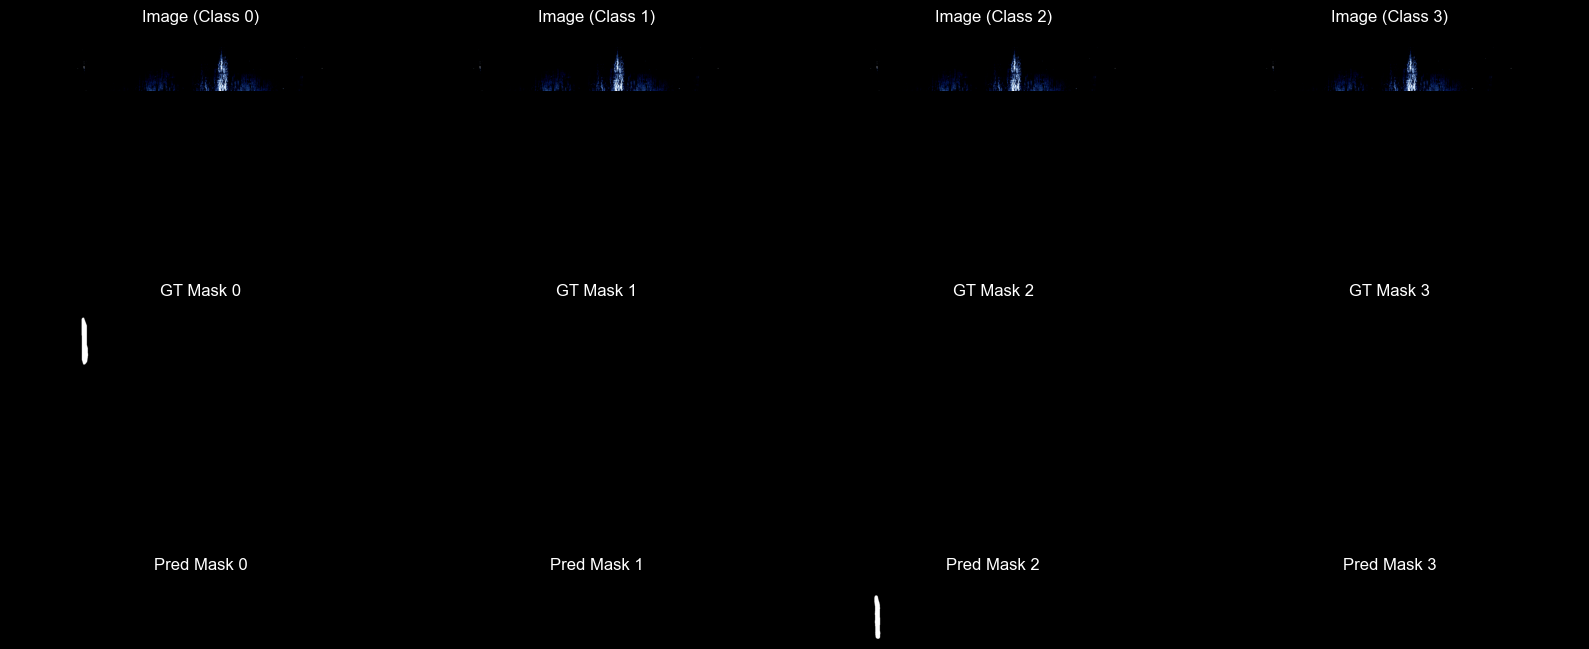

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500386..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500386..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500386..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500386..2.6399999].


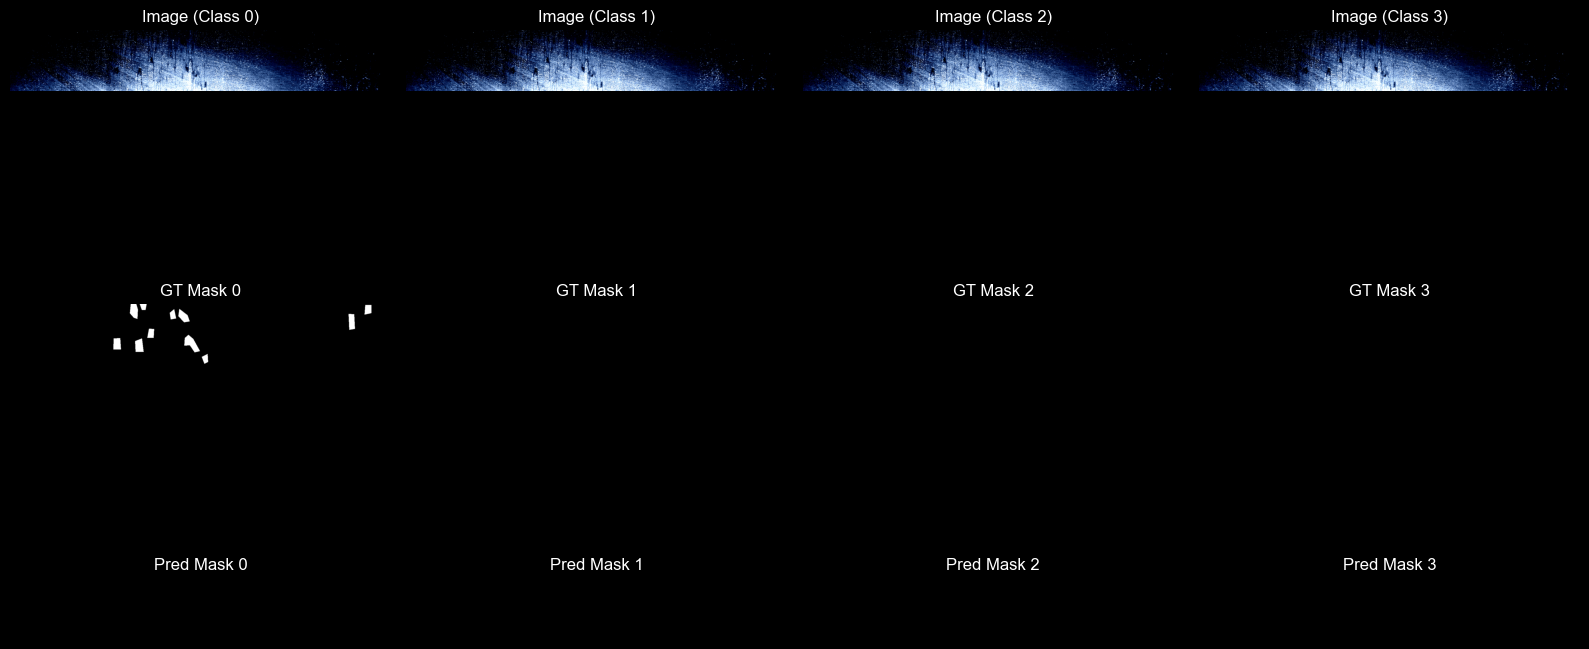

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.099695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.099695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.099695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.099695].


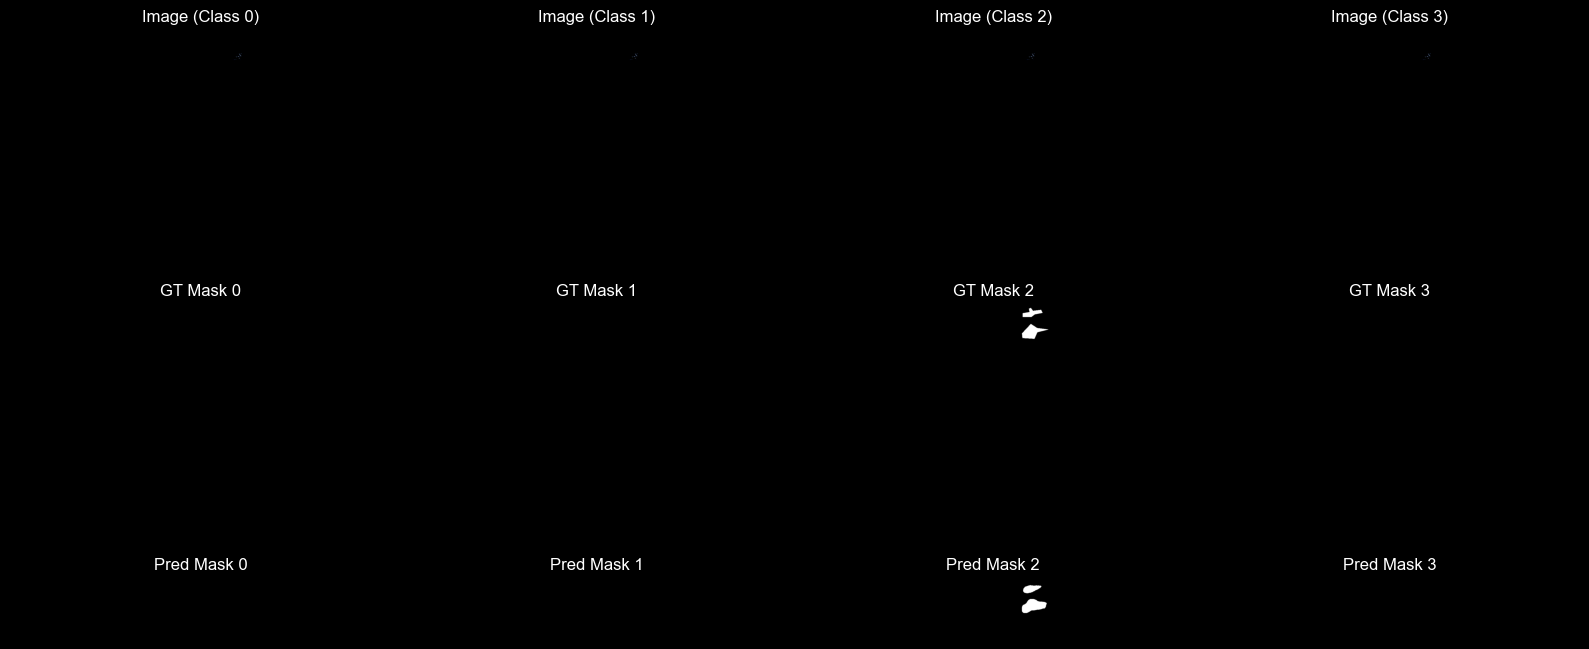

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


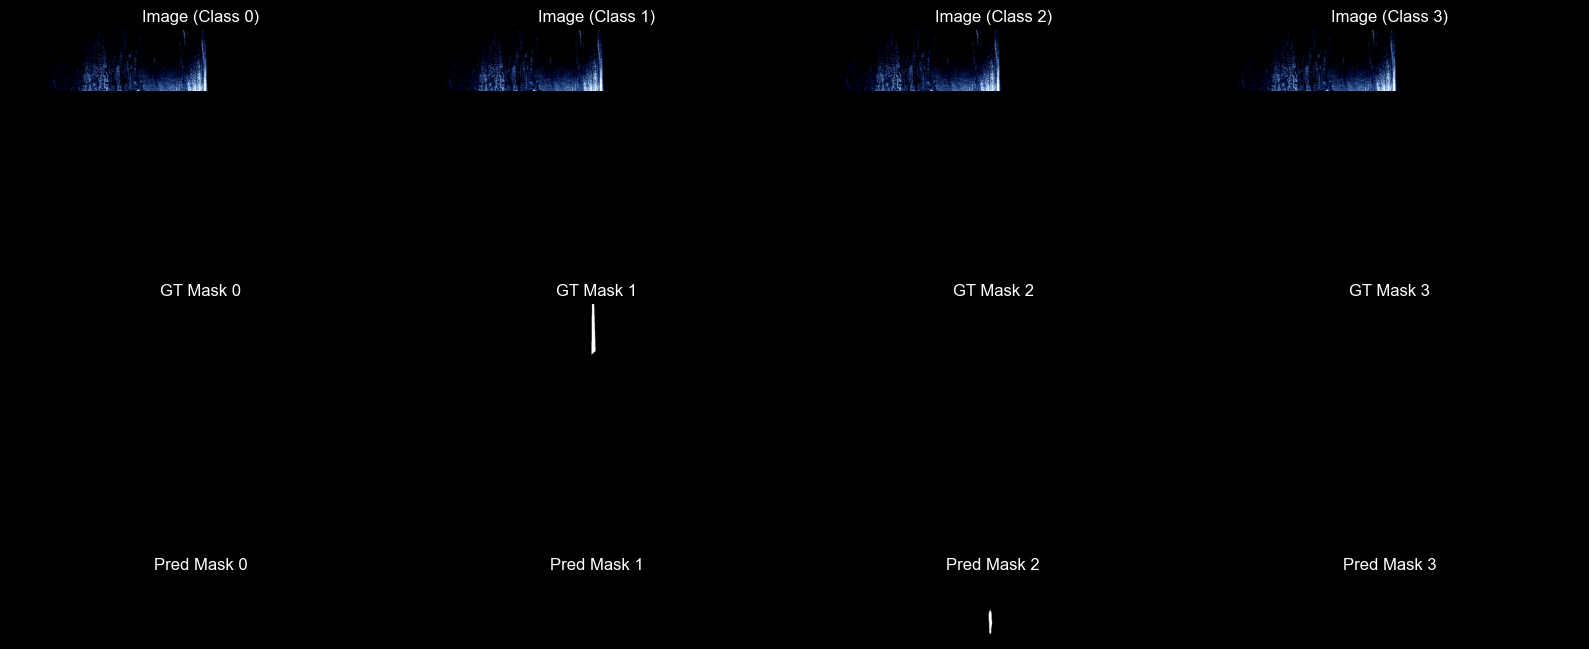

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.6399999].


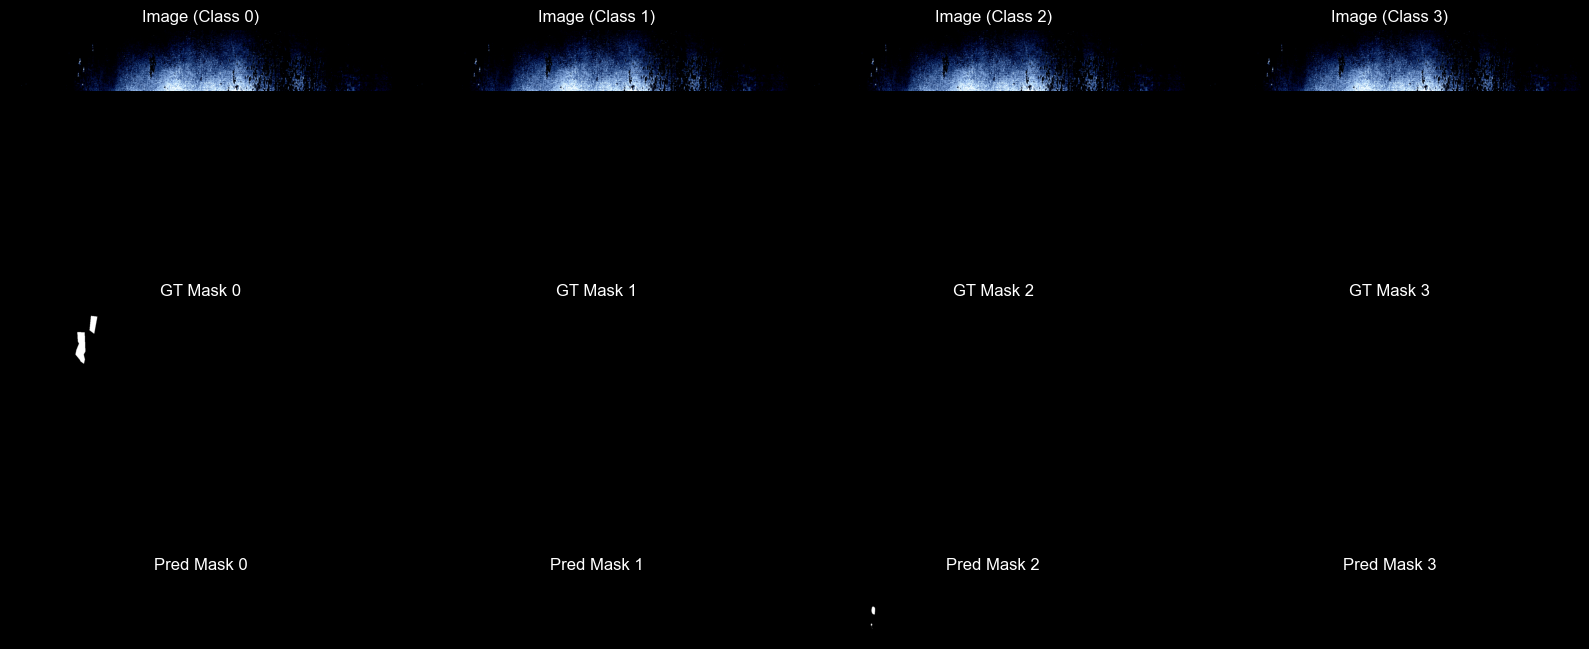

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.6399999].


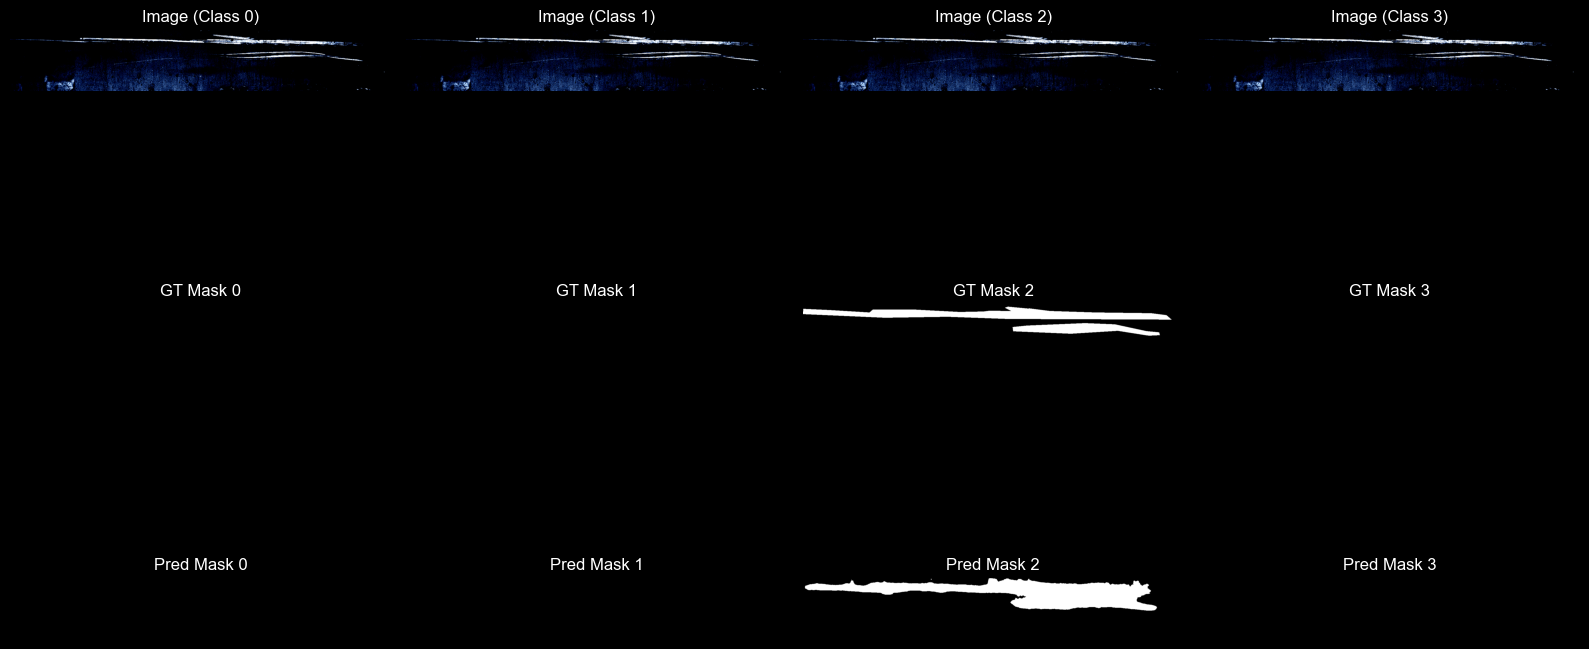

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..2.6399999].


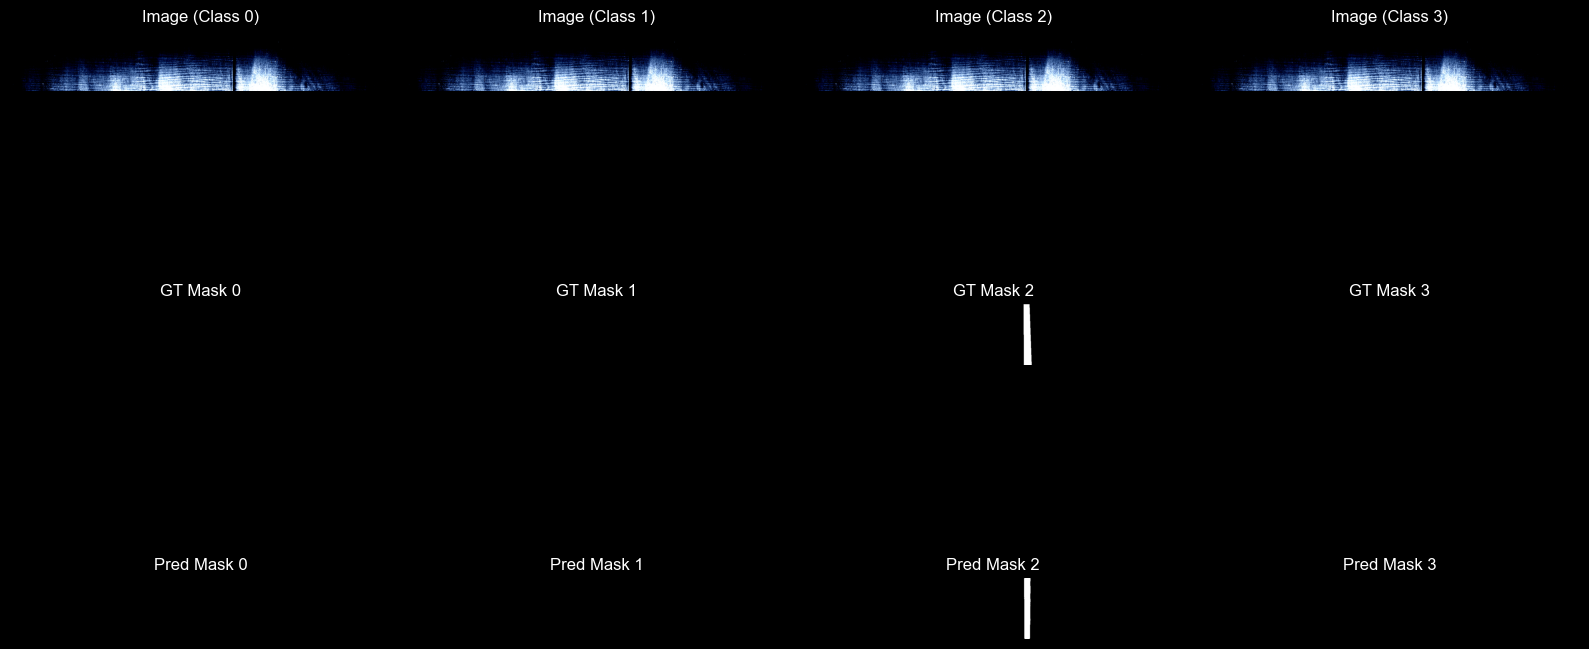

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


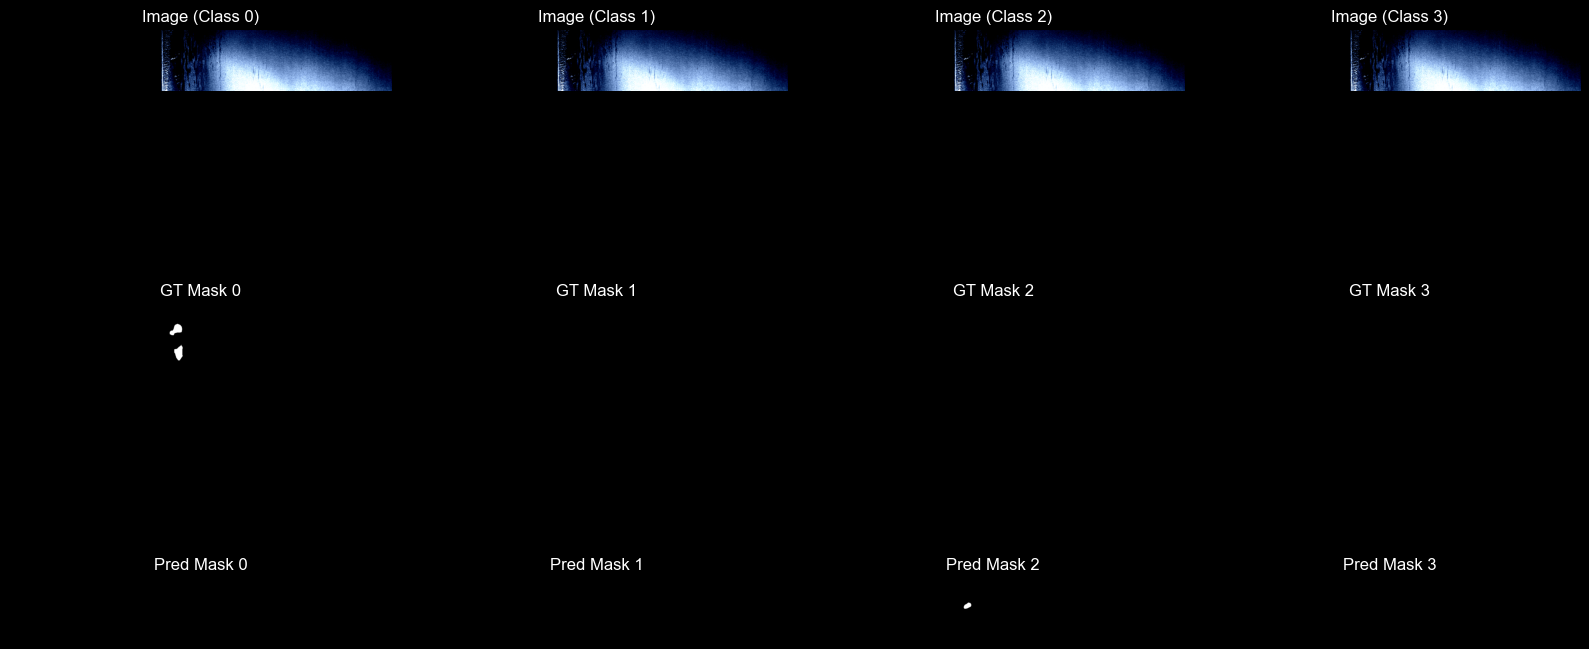

In [46]:
batch = next(iter(val_loader))

images = batch["image"].to(device)
masks = batch["mask"].to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)

for idx in range(8):
    visualize_prediction(
        images[idx],
        masks[idx],
        outputs[idx]
    )